<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/c70_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

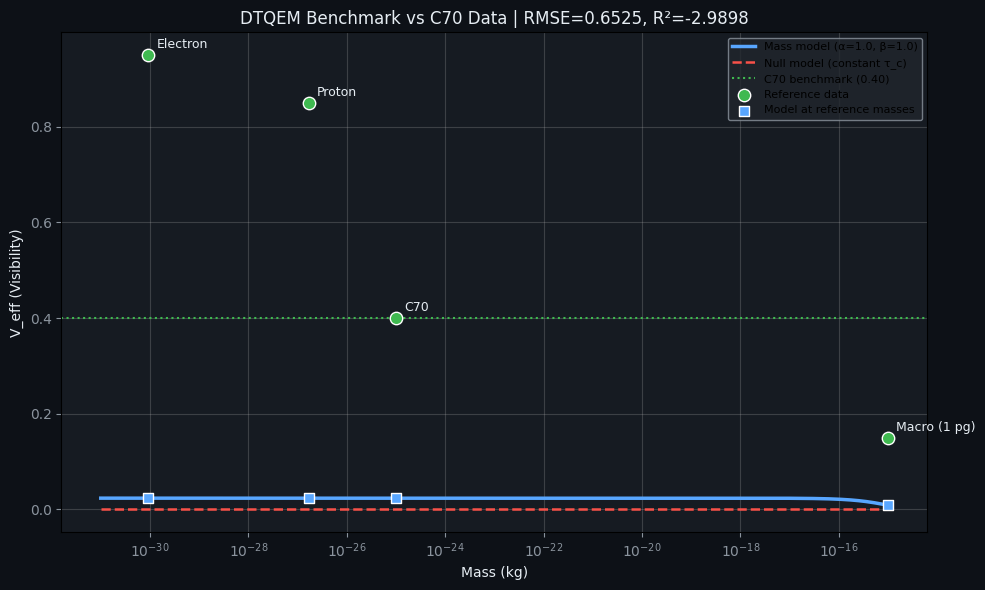

C70 Benchmark — DTQEM Mass Model Comparison
α (velocity exponent) = 1.0
β (mass exponent) = 1.0
τ_c0 = 2.500e-22 s
V_env = 0.023518
Δτ_MZ = 2.500e-07 s

Reference Data vs Model:
------------------------------------------------------------------------
Particle        Mass (kg)    Ref V      Model V    Null V    
------------------------------------------------------------------------
Electron        9.109e-31   0.950      0.024      0.000
Proton          1.673e-27   0.850      0.024      0.000
C70             9.963e-26   0.400      0.024      0.000
Macro (1 pg)    1.000e-15   0.150      0.009      0.000
------------------------------------------------------------------------
RMSE (mass model) = 0.652526
RMSE (null model) = 0.672216
R² (mass model) = -2.989834
R² (null model) = -3.234261
PNG saved to: output/c70_benchmark.png
CSV saved to: output/c70_benchmark_results.csv


In [5]:

"""
c70_benchmark.py
=================
Experimental Benchmark: DTQEM Model Comparison with C70 Interferometry Data

EXPERIMENTAL — NOT PART OF BASELINE D0

This module compares the DTQEM mass-dependent decoherence model with published
benchmark data for C70 molecules in a Talbot-Lau interferometer. The reference
visibility for C70 is approximately 0.40 (40%), as reported in the literature.

The model assumes:
    τ_c(m) = τ_c0 * (m_ref / m)**β / (γ**α)

The code:
    - Plots visibility vs mass for the mass model and a null model (constant τ_c).
    - Highlights the C70 benchmark point.
    - Computes RMSE and R² for both models against reference data points
      (Electron, Proton, C70, Macro).
    - Saves results as PNG and CSV.

Reference Data (approximate):
    - Electron: mass = 9.11e-31 kg, visibility ≈ 0.95
    - Proton:   mass = 1.67e-27 kg, visibility ≈ 0.85
    - C70:      mass = 9.96e-26 kg, visibility = 0.40 (benchmark)
    - Macro (1 pg): mass = 1e-15 kg, visibility ≈ 0.15 (hypothetical)

Purpose:
    - Provide a quantitative comparison between DTQEM and a simple constant-τ_c model.
    - Help tune α, β, τ_c0 parameters to match experimental data.
    - Serve as a foundation for future fitting to real experimental data.

Author : DTQEM Team — Berramdane Reddouane
AI Contribution: Claude (Anthropic) — coding, optimization, and documentation
Version: 2.0 (benchmark)
Date: 2026-05-24
License: MIT
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import csv

# ============================================================================
# Physical Constants
# ============================================================================
C_LIGHT = 299_792_458.0          # speed of light [m/s]
LORENTZ_SAFETY = 0.9999          # safety threshold for v/c

# ============================================================================
# Core Physics Functions (Mach-Zehnder, same as v46.0)
# ============================================================================

def lorentz_gamma(v: float) -> float:
    """Lorentz factor γ = 1 / √(1 - (v/c)²)."""
    beta = np.clip(abs(v) / C_LIGHT, 0.0, LORENTZ_SAFETY)
    return 1.0 / np.sqrt(1.0 - beta**2)


def tau_lab(L: float, v: float) -> float:
    """Lab-frame transit time: τ = L / v [s]."""
    return L / v if v > 0 else np.inf


def tau_proper(L: float, v: float) -> float:
    """Proper time along one arm: τ* = τ / γ = L / (v·γ) [s]."""
    return tau_lab(L, v) / lorentz_gamma(v)


def delta_tau_MZ(L1: float, v1: float, L2: float, v2: float) -> float:
    """Proper-time mismatch between arms: Δτ_MZ = |τ₁* − τ₂*|."""
    return abs(tau_proper(L1, v1) - tau_proper(L2, v2))


def T_eff_fn(L1: float, v1: float, L2: float, v2: float) -> float:
    """Effective environmental interaction time: T_eff = (τ₁ + τ₂)/2 [s]."""
    return 0.5 * (tau_lab(L1, v1) + tau_lab(L2, v2))


def V_env(T_eff: float, gamma_phi: float) -> float:
    """Environmental decoherence: V_env = exp(-γ_φ · T_eff)."""
    return np.exp(-gamma_phi * T_eff)


def V_dtqem(delta_tau: float, tau_c: np.ndarray) -> np.ndarray:
    """DTQEM decoherence: V_dtqem = exp(-|Δτ| / τ_c)."""
    return np.exp(-delta_tau / np.maximum(tau_c, 1e-300))


def V_eff_MZ(L1: float, v1: float, L2: float, v2: float,
             gamma_phi: float, tau_c: float) -> float:
    """Total coherence: V_eff = V_env × V_dtqem (scalar version)."""
    T_eff = T_eff_fn(L1, v1, L2, v2)
    dt = delta_tau_MZ(L1, v1, L2, v2)
    return V_env(T_eff, gamma_phi) * V_dtqem(dt, np.array([tau_c]))[0]


# ============================================================================
# Mass-Dependent τ_c Model (Experimental)
# ============================================================================

def tau_c_mass_dependent(mass: np.ndarray, tau_c0: float,
                         gamma_ref: float,
                         alpha: float = 1.0,
                         beta: float = 1.0,
                         m_ref: float = 1.0) -> np.ndarray:
    """
    Mass-dependent coherence time (experimental).

    Formula:
        τ_c(m) = τ_c0 * (m_ref / m)**β / (γ_ref**α)

    Args:
        mass: Particle mass [kg] (can be array).
        tau_c0: Base coherence time at m = m_ref, γ = 1.
        gamma_ref: Lorentz factor at reference velocity.
        alpha: Exponent for γ (velocity sensitivity).
        beta:  Exponent for mass (mass sensitivity).
        m_ref: Reference mass [kg] (default 1 kg).

    Returns:
        Effective τ_c [s] (same shape as mass).
    """
    mass = np.asarray(mass, dtype=float)
    return tau_c0 * (m_ref / mass) ** beta / (gamma_ref ** alpha)


def model_visibility(mass: np.ndarray, tau_c0: float, gamma_ref: float,
                     alpha: float, beta: float, delta_tau_val: float,
                     V_env_val: float) -> np.ndarray:
    """
    Compute visibility V_eff for a range of masses using the mass-dependent model.
    """
    tau_c_eff = tau_c_mass_dependent(mass, tau_c0, gamma_ref, alpha, beta)
    V_dtq = V_dtqem(delta_tau_val, tau_c_eff)
    return V_env_val * V_dtq


# ============================================================================
# Main Benchmark
# ============================================================================

def main():
    # Output directory
    out_dir = Path("output")
    out_dir.mkdir(exist_ok=True)

    # ========================================================================
    # Fixed Mach-Zehnder Parameters (same as v46.0)
    # ========================================================================
    L1, L2 = 0.5, 0.5           # arm lengths [m]
    v1, v2 = 1e6, 2e6           # particle velocities [m/s]
    gamma_phi = 1e7             # environmental decoherence rate [Hz]
    tau_c0 = 2.5e-22            # base coherence time [s]
    alpha = 1.0                 # exponent for γ (velocity)
    beta = 1.0                  # exponent for mass
    m_ref = 1.0                 # reference mass [kg]

    # Reference velocity and Lorentz factor
    v_ref = 0.5 * (v1 + v2)
    gamma_ref = lorentz_gamma(v_ref)

    # Base Mach-Zehnder quantities (mass-independent)
    delta_tau_val = delta_tau_MZ(L1, v1, L2, v2)
    T_eff_val = T_eff_fn(L1, v1, L2, v2)
    V_env_val = V_env(T_eff_val, gamma_phi)

    # ========================================================================
    # Reference Data Points (mass, visibility)
    # ========================================================================
    ref_data = [
        ("Electron", 9.109383701e-31, 0.95),
        ("Proton", 1.67262192369e-27, 0.85),
        ("C70", 60 * 1.66053906660e-27, 0.40),
        ("Macro (1 pg)", 1e-15, 0.15),
    ]
    ref_masses = np.array([m for _, m, _ in ref_data])
    ref_vis = np.array([v for _, _, v in ref_data])

    # ========================================================================
    # Mass Sweep for Plotting
    # ========================================================================
    masses = np.logspace(-31, -15, 400)

    # Mass-dependent model
    V_model = model_visibility(masses, tau_c0, gamma_ref, alpha, beta,
                               delta_tau_val, V_env_val)

    # Null model (constant τ_c = tau_c0)
    V_null = V_env_val * V_dtqem(delta_tau_val, tau_c0 * np.ones_like(masses))

    # ========================================================================
    # Model Predictions at Reference Masses
    # ========================================================================
    model_at_ref = model_visibility(ref_masses, tau_c0, gamma_ref, alpha, beta,
                                    delta_tau_val, V_env_val)

    # Null model predictions at reference masses
    null_at_ref = V_env_val * V_dtqem(delta_tau_val, tau_c0 * np.ones_like(ref_masses))

    # ========================================================================
    # Error Metrics
    # ========================================================================
    rmse_model = float(np.sqrt(np.mean((model_at_ref - ref_vis) ** 2)))
    rmse_null = float(np.sqrt(np.mean((null_at_ref - ref_vis) ** 2)))

    ss_res_model = np.sum((model_at_ref - ref_vis) ** 2)
    ss_res_null = np.sum((null_at_ref - ref_vis) ** 2)
    ss_tot = np.sum((ref_vis - np.mean(ref_vis)) ** 2)

    r2_model = 1 - ss_res_model / ss_tot if ss_tot > 0 else np.nan
    r2_null = 1 - ss_res_null / ss_tot if ss_tot > 0 else np.nan

    # ========================================================================
    # Plotting
    # ========================================================================
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#161b22')

    # Plot curves
    ax.semilogx(masses, V_model, color='#58a6ff', lw=2.5,
                label=f'Mass model (α={alpha}, β={beta})')
    ax.semilogx(masses, V_null, color='#f85149', lw=1.8, ls='--',
                label='Null model (constant τ_c)')

    # Reference line for C70 benchmark
    ax.axhline(0.40, color='#3fb950', lw=1.5, ls=':', label='C70 benchmark (0.40)')

    # Reference points
    ax.scatter(ref_masses, ref_vis, s=80, color='#3fb950', edgecolor='white',
               zorder=5, label='Reference data')
    ax.scatter(ref_masses, model_at_ref, s=60, color='#58a6ff', edgecolor='white',
               zorder=5, marker='s', label='Model at reference masses')

    # Annotate reference points
    for name, m, v in ref_data:
        idx = np.argmin(np.abs(ref_masses - m))
        ax.annotate(name, (m, ref_vis[idx]), xytext=(6, 5),
                    textcoords='offset points', fontsize=9, color='#e6edf3')

    ax.set_xlabel('Mass (kg)', color='#e6edf3')
    ax.set_ylabel('V_eff (Visibility)', color='#e6edf3')
    ax.set_title(f'DTQEM Benchmark vs C70 Data | RMSE={rmse_model:.4f}, R²={r2_model:.4f}',
                 color='#e6edf3')
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, facecolor='#21262d', edgecolor='#8b949e')
    ax.tick_params(colors='#8b949e')

    plt.tight_layout()

    # Save PNG
    out_png = out_dir / 'c70_benchmark.png'
    fig.savefig(out_png, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    plt.close(fig)

    # ========================================================================
    # Export CSV
    # ========================================================================
    out_csv = out_dir / 'c70_benchmark_results.csv'
    with out_csv.open('w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['metric', 'value'])
        writer.writerow(['alpha', alpha])
        writer.writerow(['beta', beta])
        writer.writerow(['tau_c0', f'{tau_c0:.3e}'])
        writer.writerow(['V_env', f'{V_env_val:.6f}'])
        writer.writerow(['delta_tau_MZ', f'{delta_tau_val:.3e}'])
        writer.writerow(['rmse_model', f'{rmse_model:.6f}'])
        writer.writerow(['rmse_null', f'{rmse_null:.6f}'])
        writer.writerow(['r2_model', f'{r2_model:.6f}'])
        writer.writerow(['r2_null', f'{r2_null:.6f}'])

    # ========================================================================
    # Console Summary
    # ========================================================================
    print('=' * 72)
    print('C70 Benchmark — DTQEM Mass Model Comparison')
    print('=' * 72)
    print(f'α (velocity exponent) = {alpha}')
    print(f'β (mass exponent) = {beta}')
    print(f'τ_c0 = {tau_c0:.3e} s')
    print(f'V_env = {V_env_val:.6f}')
    print(f'Δτ_MZ = {delta_tau_val:.3e} s')
    print()
    print('Reference Data vs Model:')
    print('-' * 72)
    print(f"{'Particle':<15} {'Mass (kg)':<12} {'Ref V':<10} {'Model V':<10} {'Null V':<10}")
    print('-' * 72)
    for i, (name, m, v_ref) in enumerate(ref_data):
        print(f'{name:<15} {m:.3e}   {v_ref:.3f}      {model_at_ref[i]:.3f}      {null_at_ref[i]:.3f}')
    print('-' * 72)
    print(f'RMSE (mass model) = {rmse_model:.6f}')
    print(f'RMSE (null model) = {rmse_null:.6f}')
    print(f'R² (mass model) = {r2_model:.6f}')
    print(f'R² (null model) = {r2_null:.6f}')
    print('=' * 72)
    print(f'PNG saved to: {out_png}')
    print(f'CSV saved to: {out_csv}')
    print('=' * 72)


if __name__ == "__main__":
    main()